In [ ]:
# !pip install medmnist --quiet
# !pip install torch --quiet
# !pip install torchvision --quiet
# !pip install lightning  --quiet
# !pip install matplotlib --quiet
# !pip install scipy==1.11.3 --quiet
# !pip torchkbnufft scipy==1.11.3 --quiet
# import torch


In [2]:
import torch
from torch import nn

class ReLULayer(nn.Module):
    def __init__(self,
                 in_size: int,
                 out_size: int,
                 **kwargs):
        super().__init__()
        self.linear = nn.Linear(in_size, out_size, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.linear(x)
        x = torch.relu(x)
        return x


class MLP(nn.Module):
    def __init__(self,
                 in_size: int,
                 out_size: int,
                 hidden_size: int = 128,
                 num_layers: int = 3,
                 layer_class: nn.Module = ReLULayer,
                 **kwargs):
        super().__init__()

        a = [layer_class(in_size, hidden_size, **kwargs)]
        for i in range(num_layers - 1):
            a.append(layer_class(hidden_size, hidden_size, **kwargs))
        a.append(nn.Linear(hidden_size, out_size))
        self.layers = nn.ModuleList(a)        

    def forward(self, x: torch.Tensor):
        for layer in self.layers:
            x = layer(x)
        return x

100%|██████████| 214384716/214384716 [01:59<00:00, 1792056.08it/s]


Image shape: torch.Size([224, 224, 1])
Max: tensor(0.8980) Min: tensor(0.)


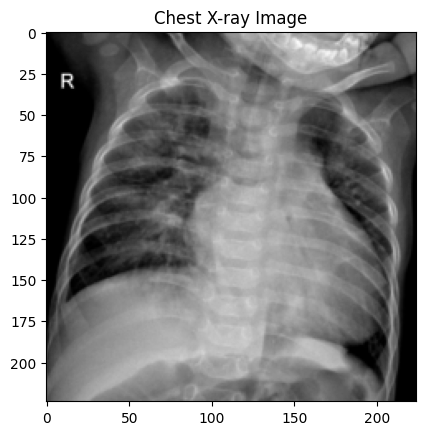

In [3]:
from medmnist import BreastMNIST, RetinaMNIST, PneumoniaMNIST
from torchvision.transforms.functional import pil_to_tensor
import matplotlib.pyplot as plt

IMAGE_SIZE = 224  # ChestMNIST offers sizes: 28, 64, 128, 224
chest_dataset = PneumoniaMNIST(split="val",
                           download=True,
                           size=IMAGE_SIZE)

# INRs are trained on only 1 scene. We only want 1 image.
pil_image, _ = chest_dataset[1]

gt_image = pil_to_tensor(pil_image)
gt_image = gt_image.moveaxis(0, -1)  # Convert to torch.Tensor
gt_image = gt_image.to(torch.float32) / 255.0  # Normalize image between [0.0, 1.0]
print("Image shape:", gt_image.shape)
print("Max:", gt_image.max(), "Min:", gt_image.min())
plt.imshow(gt_image, cmap='gray')
plt.title('Chest X-ray Image')
plt.show()

In [61]:
# gt_image.shape
# temp = torch.rand(172, 192, 192, 1)
from Models.models import Siren, Finer
from Utils.utils import get_full_img, norm, get_device, dice_stack_helper, get_model, ClearCache
from Data.load_data_3d import load_data, get_gt_seg
from Utils.defaults import default_config
from Utils.plotting_utils2 import plot_seg_results_paper, plot_final_results_paper, plot_hf_results_paper
from Utils.plotting_utils import loss_plot, plot_image_metrics, plot_4_images
from LFSynth.ContrastModulation import ContrastModulation
from test3D import visualize_volume_slices
import copy

config = copy.deepcopy(default_config)
config["in_features"] = 3
hf_ground_truth, lf_gt, prior_seg_dice, lf_gt_seg_dice, M = load_data(1, config) #uncomment
gt_image = torch.tensor(norm(hf_ground_truth)).unsqueeze(-1)


# gt_image = temp

Device =  mps
torch.Size([87, 96, 192])
BG Noise in different regions : 4.7445857300717 4.415978248235479 4.956849146645869 4.8247938816077935
known_m =  [0.75 0.9  0.9 ]
[[ 28.84998854   0.          -7.89492106]
 [ 28.84998854 -22.35619149   0.        ]
 [  0.          22.35619149  -7.89492106]] [14.53206245  1.51691906 13.01514339]
             m_init  epsilon  \
0   [0.1, 0.1, 0.1]     0.00   
1   [0.1, 0.1, 0.1]     0.01   
2   [0.1, 0.1, 0.1]     0.05   
3   [0.1, 0.1, 0.1]     0.10   
4   [0.1, 0.1, 0.1]     0.20   
..              ...      ...   
59  [0.5, 0.5, 0.5]     0.10   
60  [0.5, 0.5, 0.5]     0.20   
61  [0.5, 0.5, 0.5]     0.30   
62  [0.5, 0.5, 0.5]     0.40   
63  [0.5, 0.5, 0.5]     0.50   

                                                 loss  \
0   [144.631340676391, 144.63133495698293, 144.631...   
1   [144.63164067639102, 144.63163495701272, 144.6...   
2   [144.632840676391, 144.63283495713193, 144.632...   
3   [144.634340676391, 144.63433495728094, 144.634.

In [67]:
gt_image = gt_image.to(torch.float32)

In [90]:
import torch
from torch.utils.data import Dataset, DataLoader
import random
import numpy as np


POINTS_PER_SAMPLE = 96*96*4

class RandomPointsDataset(Dataset):
    def __init__(self, image: torch.Tensor, points_num: int = POINTS_PER_SAMPLE):
        super().__init__()
        self.device = "mps"
        self.points_num = points_num
        assert image.dtype == torch.float32
        self.image = image.to(self.device)  # (H, W, ..., C)
        self.dim_sizes = self.image.shape[:-1]  # Size of each spatial dimension

        # To help us define the input/output sizes of our network later
        # we store the size of our input coordinates and output values
        self.coord_size = len(self.image.shape[:-1])  # Number of spatial dimensions
        self.value_size = self.image.shape[-1]  # Channel size

    def __len__(self):
        return 1

    def __getitem__(self, idx: int):
        # Create random sample of pixel indices
        point_indices = [torch.randint(0, i, (self.points_num,), device=self.device) for i in self.dim_sizes]

        # Retrieve image values from selected indices
        point_values = self.image[tuple(point_indices)]

        # Convert point indices into normalized [-1.0, 1.0] coordinates
        point_coords = torch.stack(point_indices, dim=-1)
        spatial_dims = torch.tensor(self.dim_sizes, device=self.device)
        point_coords_norm = point_coords / (spatial_dims / 2) - 1

        # The subject index is also returned in case the user wants to use subject-wise learned latents
        return point_coords_norm, point_values

dataset = RandomPointsDataset(gt_image, points_num=POINTS_PER_SAMPLE)
# We set a batch_size of 1 since our dataloader is already returning a batch of points.
dataloader = DataLoader(dataset, batch_size=1, num_workers=0, pin_memory=True)

In [5]:
from typing import Tuple, List, Optional
import numpy as np
import torch
import matplotlib.pyplot as plt

In [38]:
# We will track visual results every few epochs and visualize them after training
def plot_reconstructions(progress_ims: List[Tuple[int, torch.Tensor]], gt_im: torch.Tensor):
    ncols = len(progress_ims) + 1
    fig_width = 5
    fig, axs = plt.subplots(ncols=ncols, figsize=(ncols*fig_width, fig_width))
    # Plot all reconstructions images predicted by the model
    for i, (epoch, im, metric) in enumerate(progress_ims):
        im = im.cpu().numpy()
        ax = axs[i]
        ax.imshow(im, cmap='gray')
        ax.axis('off')
        title = f'Epoch: {epoch}, PSNR: {metric}'
        ax.set_title(title)
    # PLot ground-truth image
    gt_im = gt_im.cpu().numpy()
    axs[-1].imshow(gt_im, cmap='gray')
    axs[-1].axis('off')
    axs[-1].set_title('Ground Truth')
    plt.tight_layout()
    plt.show()

# We will also track the PSNR of our training samples
def psnr(pred, ref):
    max_value = ref.max()
    mse = torch.mean((pred - ref) ** 2, dim=(-2, -1))
    out = 20 * torch.log10(max_value / torch.sqrt(mse))
    return out.mean()

# Let's create a function to plot our psnr scores throughout training
def plot_scores(models: List['INRModule']):
    fig, ax = plt.subplots()
    # For each model, plot list of scores
    for model in models:
        epochs, scores = [i for i, _ in model.scores], [v for _, v in model.scores]
        ax.plot(epochs, scores, label=model.name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('PSNR')
    ax.set_title('PSNR over epochs')
    ax.legend()
    plt.show()

In [69]:
from torch import nn
import lightning as pl

class INRLightningModule(pl.LightningModule):
    def __init__(self,
                 network: MLP,
                 gt_im: torch.Tensor,
                 lr: float = 0.001,
                 name: str = "",
                 eval_interval: int = 100,
                 visualization_intervals: List[int] = [0, 100, 500, 1000, 5000, 10000],
                ):
        super().__init__()
        self.lr = lr
        self.network = network

        # Logging
        self.name = name
        self.gt_im = gt_im
        self.eval_interval = eval_interval
        self.visualization_intervals = visualization_intervals
        self.progress_ims = []
        self.scores = []

    def configure_optimizers(self):
        return torch.optim.Adam(self.network.parameters(), lr=self.lr)

    def forward(self, coords):
        return self.network(coords)

    def training_step(self, batch, batch_idx):
        coords, values = batch
        coords = coords.view(-1, coords.shape[-1])
        values = values.view(-1, values.shape[-1])
        outputs = self.forward(coords)
        loss = nn.functional.mse_loss(outputs, values)
        return loss

    def on_train_epoch_end(self):
        """ At each visualization interval, reconstruct the image using our INR """
        if (self.current_epoch + 1) % self.eval_interval == 0 or self.current_epoch == 0:
            pred_im = self.sample_at_resolution(self.gt_im.shape[:-1])
            pred_im = pred_im.reshape(self.gt_im.shape)
            psnr_value = psnr(pred_im, self.gt_im.to(pred_im.device)).cpu().item()
            self.scores.append((self.current_epoch + 1, psnr_value))  # Log PSNR
            if self.current_epoch + 1 in self.visualization_intervals:
                self.progress_ims.append((self.current_epoch + 1, pred_im.cpu(), psnr_value))

    @torch.no_grad()
    def sample_at_resolution(self, resolution: Tuple[int, ...]):
        """ Evaluate our INR on a grid of coordinates in order to obtain an image. """
        meshgrid = torch.meshgrid([torch.arange(0, i, device=self.device) for i in resolution], indexing='ij')
        coords = torch.stack(meshgrid, dim=-1)
        coords_norm = coords / torch.tensor(resolution, device=self.device) * 2 - 1
        coords_norm_ = coords_norm.reshape(-1, coords.shape[-1])
        predictions_ = self.forward(coords_norm_)
        predictions = predictions_.reshape(resolution)
        return predictions

In [94]:
# Let's initialize our network
HIDDEN_SIZE = 512
NUM_LAYERS = 9

inr = MLP(dataset.coord_size,
          dataset.value_size,
          hidden_size=HIDDEN_SIZE,
          num_layers=NUM_LAYERS,
          layer_class=ReLULayer, 
         )


In [95]:
from datetime import datetime

# Let's initialize our lightning module
LEARNING_RATE = 1e-3
TRAINING_EPOCHS = 5000

inr_module = INRLightningModule(network=inr, 
                                lr=LEARNING_RATE,
                                gt_im=gt_image,
                                name='ReLU',
                                eval_interval=100,
                                visualization_intervals=[0, 100, 500, 1000, 5000, 10000],
                                )
trainer = pl.Trainer(max_epochs=TRAINING_EPOCHS)
s = datetime.now()
trainer.fit(inr_module, train_dataloaders=dataloader)
print(f"Fitting time: {datetime.now()-s}s.")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type | Params | Mode 
-----------------------------------------
0 | network | MLP  | 2.1 M  | train
-----------------------------------------
2.1 M     Trainable params
0         Non-trainable params
2.1 M     Total params
8.415     Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


AttributeError: 'tuple' object has no attribute 'tb_frame'

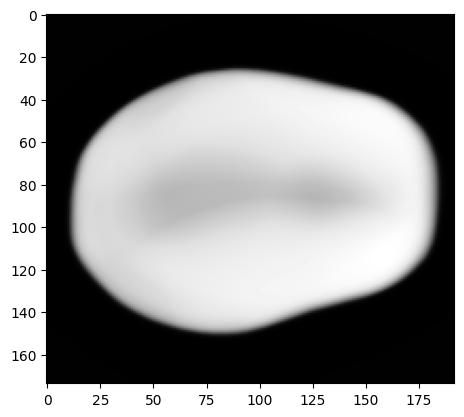

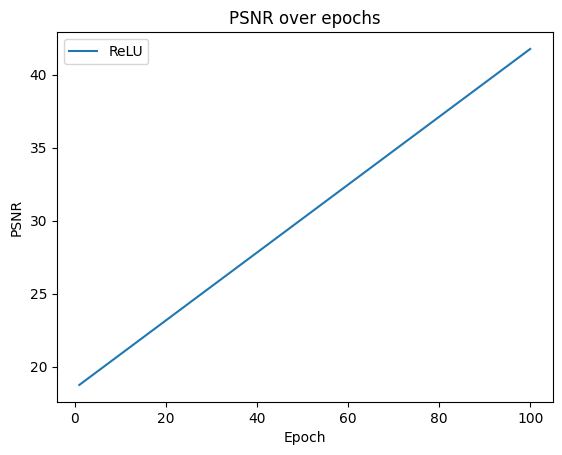

In [96]:
# Let's visualize the reconstruction progress during training!
# plot_reconstructions(inr_module.progress_ims, gt_image)
pred_img = inr_module.sample_at_resolution(gt_image.shape[:-1])
plt.imshow(pred_img[:,:,95], cmap='gray')
plot_scores([inr_module])